# 01. EdgeMTSC

### Что делаю?

Собираю EdgeMTSC по training topology официального репозитория: `channel-fixing -> IMP-SKB -> IMP-LKB -> sAC`. Оставляю именно части, которые нужны для проверки идей статьи, без deployment-конвертации SRP.

Оригинальный repo: https://github.com/HokyeeJau/EdgeMTSC

Статья: `EdgeMTSC: A Lightweight Large-Kernel ConvNet for Multivariate Time Series Classification`, AAAI 2026.

![EdgeMTSC](../docs/assets/edgemtsc_architecture.png)

Важные части:

- `IMP` -- learnable message passing между latent channels с residual;
- `SKB` -- короткие depthwise kernels `3` и `1`, локальные зависимости;
- `LKB` -- большой kernel `47` + dilated branches из repo, длинные и stride-sampled зависимости;
- `sAC` -- две классификационные головы.

Structural re-parameterization здесь не делаю -- она нужна для схлопывания веток после обучения и отдельного deployment-бенчмарка, а сами train-time блоки остаются теми же.


In [1]:
from pathlib import Path
from copy import deepcopy
import json
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
(ROOT / "figures").mkdir(exist_ok=True)
(ROOT / "results").mkdir(exist_ok=True)

data = np.load(ROOT / "data/uci_har_raw.npz")
X_train = data["X_train"]
y_train = data["y_train"]
subjects_train = data["subjects_train"]
X_test = data["X_test"]
y_test = data["y_test"]

CLASS_NAMES = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING",
]

SEED = 42
BATCH_SIZE = 128
MAX_EPOCHS = 35
PATIENCE = 7
LR = 8e-4
WEIGHT_DECAY = 1e-3
LABEL_SMOOTHING = 0.05

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: mps


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def standardize(X_fit, X_other):
    mean = X_fit.mean(axis=(0, 2), keepdims=True)
    std = X_fit.std(axis=(0, 2), keepdims=True) + 1e-6
    return (X_fit - mean) / std, (X_other - mean) / std, mean, std


def make_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []
    loss_sum = 0.0
    criterion = nn.CrossEntropyLoss()

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss_sum += criterion(logits, y).item() * len(y)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(logits.argmax(1).cpu().numpy())

    return {
        "loss": loss_sum / len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": np.asarray(y_true),
        "y_pred": np.asarray(y_pred),
    }


def fit(model, train_loader, val_loader=None, epochs=MAX_EPOCHS):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_f1": []}
    best_state = deepcopy(model.state_dict())
    best_f1, best_epoch = -1.0, 0
    started = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum, correct, total = 0.0, 0, 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            loss_sum += loss.item() * len(y)
            correct += (logits.argmax(1) == y).sum().item()
            total += len(y)

        scheduler.step()
        history["train_loss"].append(loss_sum / total)
        history["train_acc"].append(correct / total)

        if val_loader is not None:
            val = evaluate(model, val_loader)
            history["val_loss"].append(val["loss"])
            history["val_f1"].append(val["macro_f1"])

            if val["macro_f1"] > best_f1:
                best_f1 = val["macro_f1"]
                best_epoch = epoch
                best_state = deepcopy(model.state_dict())

            if epoch - best_epoch >= PATIENCE:
                break

    if val_loader is not None:
        model.load_state_dict(best_state)

    return history, best_epoch, time.perf_counter() - started


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def sync():
    if device.type == "mps":
        torch.mps.synchronize()
    elif device.type == "cuda":
        torch.cuda.synchronize()


@torch.no_grad()
def latency_ms(model, X, repeats=100):
    model.eval()
    batch = torch.tensor(X[:BATCH_SIZE], dtype=torch.float32, device=device)
    for _ in range(20):
        model(batch)
    sync()
    started = time.perf_counter()
    for _ in range(repeats):
        model(batch)
    sync()
    return (time.perf_counter() - started) * 1000 / repeats / len(batch)


### Архитектура

Обучаю на ноуте, поэтому держу общий budget около `180k` trainable params. Для standard EdgeMTSC беру `hidden=(352, 88)`: модель остается компактной, но по факту уже дает качество на уровне нормального raw-signal HAR baseline.


In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=1, padding=0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.block(x)


class IMP(nn.Module):
    # Здесь передаю сообщения между latent channels -- одна матрица C x C действует на весь ряд.
    def __init__(self, channels, seq_len):
        super().__init__()
        self.mix = nn.Linear(channels, channels, bias=False)
        self.bn = nn.BatchNorm1d(seq_len)

    def forward(self, x):
        x_t = x.transpose(1, 2)
        return F.relu(self.bn(self.mix(x_t) + x_t).transpose(1, 2))


class SKB(nn.Module):
    # Здесь короткими kernels собираю локальные timelets.
    def __init__(self, channels):
        super().__init__()
        self.conv3 = nn.Conv1d(channels, channels, 3, padding=1, groups=channels, bias=False)
        self.conv1 = nn.Conv1d(channels, channels, 1, groups=channels, bias=False)
        self.bn3 = nn.BatchNorm1d(channels)
        self.bn1 = nn.BatchNorm1d(channels)
        self.bn_id = nn.BatchNorm1d(channels)

    def forward(self, x):
        return F.relu(self.bn3(self.conv3(x)) + self.bn1(self.conv1(x)) + self.bn_id(x))


class LKB(nn.Module):
    # Здесь беру K=47 и dilated branches из официального EdgeMTSC repo.
    def __init__(self, channels, multiscale=True):
        super().__init__()
        self.origin = nn.Sequential(
            nn.Conv1d(channels, channels, 47, padding=23, groups=channels, bias=False),
            nn.BatchNorm1d(channels),
        )
        self.branches = nn.ModuleList()

        if multiscale:
            for kernel, dilation in zip([5, 23, 3, 3, 3], [1, 2, 21, 19, 17]):
                padding = (dilation * (kernel - 1) + 1) // 2
                self.branches.append(nn.Sequential(
                    nn.Conv1d(
                        channels, channels, kernel,
                        padding=padding, dilation=dilation,
                        groups=channels, bias=False,
                    ),
                    nn.BatchNorm1d(channels),
                ))

    def forward(self, x):
        out = self.origin(x)
        for branch in self.branches:
            out = out + branch(x)
        return out + x


class EdgeMTSC(nn.Module):
    def __init__(self, hidden=(352, 88), dropout=0.2, use_imp=True, multiscale=True):
        super().__init__()
        h1, h2 = hidden

        self.up1 = ConvBlock(9, h1)
        self.imp1 = IMP(h1, 128) if use_imp else nn.Identity()
        self.skb = SKB(h1)

        self.up2 = ConvBlock(h1, h2)
        self.imp2 = IMP(h2, 128) if use_imp else nn.Identity()
        self.lkb = LKB(h2, multiscale=multiscale)

        # Здесь оставляю sAC из двух голов, как в repo, и усредняю их logits.
        self.linear_head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(h2, 6)
        )
        self.conv_head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(h2, 6, 1),
            nn.BatchNorm1d(6),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Flatten(),
        )

    def forward(self, x):
        x = self.skb(self.imp1(self.up1(x)))
        x = self.imp2(self.up2(x))
        x = F.relu(self.lkb(x) + x)
        return (self.linear_head(x) + self.conv_head(x)) / 2


In [4]:
set_seed(SEED)
model = EdgeMTSC().to(device)
print(model)
print("params:", f"{count_parameters(model):,}")


EdgeMTSC(
  (up1): ConvBlock(
    (block): Sequential(
      (0): Conv1d(9, 352, kernel_size=(1,), stride=(1,), bias=False)
      (1): BatchNorm1d(352, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
    )
  )
  (imp1): IMP(
    (mix): Linear(in_features=352, out_features=352, bias=False)
    (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (skb): SKB(
    (conv3): Conv1d(352, 352, kernel_size=(3,), stride=(1,), padding=(1,), groups=352, bias=False)
    (conv1): Conv1d(352, 352, kernel_size=(1,), stride=(1,), groups=352, bias=False)
    (bn3): BatchNorm1d(352, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (bn1): BatchNorm1d(352, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (bn_id): BatchNorm1d(352, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (up2): ConvBlock(
    (block): Sequential(
 

### 3-fold GroupKFold

CV делаю по `subject_id`, а не случайно по окнам -- окна одного человека не должны одновременно попадать в train и validation.

На каждом fold отдельно считаю z-score только по train части. Official test здесь вообще не используется.


In [5]:
gkf = GroupKFold(n_splits=3)
cv_rows, cv_histories = [], []
fold_splits = list(gkf.split(X_train, y_train, groups=subjects_train))

for fold, (train_idx, val_idx) in enumerate(fold_splits, 1):
    set_seed(SEED + fold)

    X_fit, X_val, _, _ = standardize(X_train[train_idx], X_train[val_idx])
    train_loader = make_loader(X_fit, y_train[train_idx], shuffle=True)
    val_loader = make_loader(X_val, y_train[val_idx])

    model = EdgeMTSC().to(device)
    history, best_epoch, elapsed = fit(model, train_loader, val_loader)
    val = evaluate(model, val_loader)

    cv_histories.append(history)
    cv_rows.append({
        "fold": fold,
        "best_epoch": best_epoch,
        "accuracy": val["accuracy"],
        "balanced_accuracy": val["balanced_accuracy"],
        "macro_f1": val["macro_f1"],
        "time_s": elapsed,
    })

cv_df = pd.DataFrame(cv_rows)
cv_df


,fold,best_epoch,accuracy,balanced_accuracy,macro_f1,time_s
0,1,9,0.971288,0.97329,0.972348,26.330966
1,2,6,0.858886,0.86484,0.860999,20.022456
2,3,12,0.953157,0.95671,0.956504,28.549341


In [6]:
print(cv_df[["accuracy", "balanced_accuracy", "macro_f1"]].agg(["mean", "std"]).round(4))


      accuracy  balanced_accuracy  macro_f1
mean    0.9278             0.9316    0.9300
std     0.0603             0.0584    0.0602


Средний `macro F1 = 0.9300`, но разброс между группами людей заметный. Второй fold сложнее для всех моделей в работе: здесь EdgeMTSC дает `0.8610`, тогда как на первом и третьем -- `0.9723` и `0.9565`. Это больше похоже на разницу между subject groups, чем на случайный сбой одной архитектуры.


### Learning curves


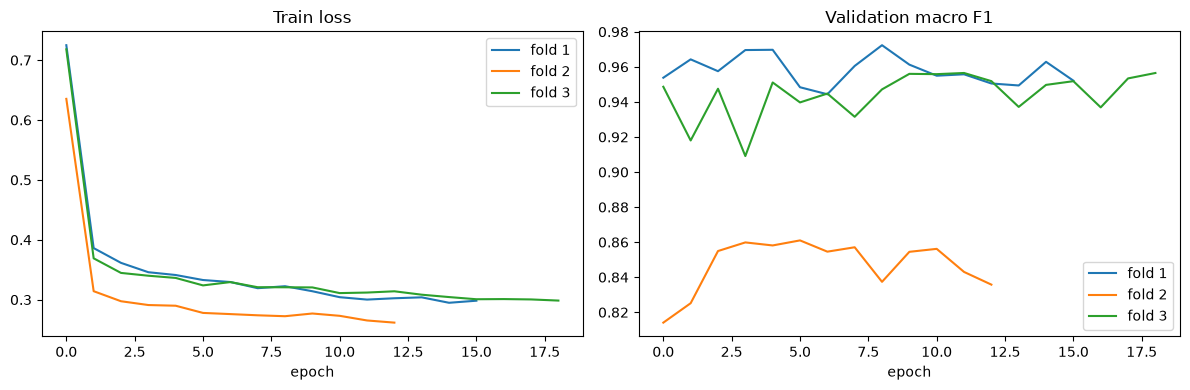

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for fold, history in enumerate(cv_histories, 1):
    axes[0].plot(history["train_loss"], label=f"fold {fold}")
    axes[1].plot(history["val_f1"], label=f"fold {fold}")
axes[0].set_title("Train loss")
axes[1].set_title("Validation macro F1")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "figures/01_edge_learning_curves.png", dpi=150)
plt.show()


По learning curves модель сходится быстро: лучшие эпохи на folds -- `9`, `6`, `12`, до лимита в `35` ни один fold не доходит. Явного смысла просто увеличивать число эпох не вижу -- после раннего максимума validation F1 начинает колебаться, поэтому early stopping здесь нужен.


### Короткая абляция ключевых идей

Основные три модели дальше сравниваю при близком числе параметров. Но для ответа на вопрос задания отдельно делаю маленькую ablation на первом CV fold:

- `w/o IMP` -- убираю межканальное message passing;
- `single-scale LKB` -- оставляю только основной kernel `47`, без dilated branches.

Это не четвертая основная baseline, а проверка двух конкретных идей статьи.


In [8]:
train_idx, val_idx = fold_splits[0]
X_fit, X_val, _, _ = standardize(X_train[train_idx], X_train[val_idx])
train_loader = make_loader(X_fit, y_train[train_idx], shuffle=True)
val_loader = make_loader(X_val, y_train[val_idx])

ablation_rows = [{
    "variant": "full EdgeMTSC",
    "macro_f1": cv_df.loc[0, "macro_f1"],
    "params": count_parameters(EdgeMTSC()),
}]

for name, kwargs in {
    "w/o IMP": {"use_imp": False},
    "single-scale LKB": {"multiscale": False},
}.items():
    set_seed(SEED)
    ablation_model = EdgeMTSC(**kwargs).to(device)
    fit(ablation_model, train_loader, val_loader)
    score = evaluate(ablation_model, val_loader)
    ablation_rows.append({
        "variant": name,
        "macro_f1": score["macro_f1"],
        "params": count_parameters(ablation_model),
    })

ablation_df = pd.DataFrame(ablation_rows)
ablation_df


,variant,macro_f1,params
0,full EdgeMTSC,0.972348,180232
1,w/o IMP,0.970479,48072
2,single-scale LKB,0.971537,176096


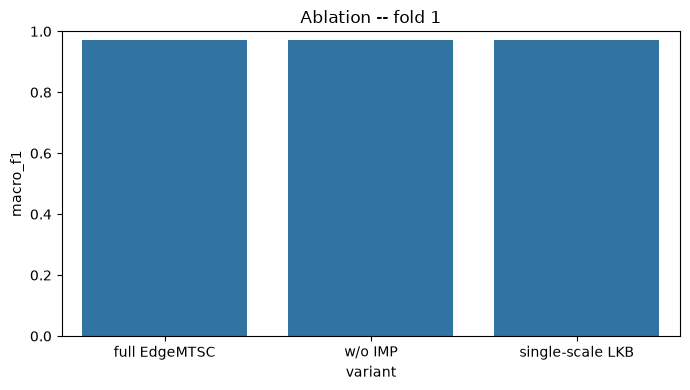

In [9]:
plt.figure(figsize=(7, 4))
sns.barplot(data=ablation_df, x="variant", y="macro_f1")
plt.ylim(0, 1)
plt.title("Ablation -- fold 1")
plt.tight_layout()
plt.savefig(ROOT / "figures/01_edge_ablation.png", dpi=150)
plt.show()


Разницы в этой короткой ablation маленькие: `w/o IMP` хуже full-модели примерно на `0.0019` macro F1, `single-scale LKB` -- на `0.0008`. Это только один subject-wise fold, поэтому трактую результат аккуратно: сильного отдельного эффекта IMP или multiscale именно на UCI HAR здесь не доказано. Плюс при удалении IMP падает и число параметров, так что это ablation блока, а не parameter-matched причинный эксперимент. Для основного сравнения дальше использую модели одного размера.


### Финальное обучение на всем official train

Количество эпох не выбираю по test -- беру медиану лучших эпох из group CV. После этого обучаю модель заново на всем train и считаю test уже для зафиксированной конфигурации.


In [10]:
final_epochs = int(np.median(cv_df["best_epoch"]))
X_fit, X_holdout, mean, std = standardize(X_train, X_test)
train_loader = make_loader(X_fit, y_train, shuffle=True)
test_loader = make_loader(X_holdout, y_test)

set_seed(SEED)
model = EdgeMTSC().to(device)
final_history, _, final_train_time = fit(model, train_loader, epochs=final_epochs)
test = evaluate(model, test_loader)
latency = latency_ms(model, X_holdout)

print("final epochs:", final_epochs)
print({k: round(v, 4) for k, v in test.items() if not k.startswith("y_")})
print("params:", f"{count_parameters(model):,}")
print("train time, s:", round(final_train_time, 2))
print("latency, ms/sample:", round(latency, 4))


final epochs: 9
{'loss': 0.263, 'accuracy': 0.9287, 'balanced_accuracy': 0.9306, 'macro_f1': 0.9293}
params: 180,232
train time, s: 17.66
latency, ms/sample: 0.06


На official test получаю `0.9287` accuracy и `0.9293` macro F1. Balanced accuracy (`0.9306`) почти совпадает с обычной accuracy -- явной просадки из-за распределения классов нет. Результат также попадает примерно в район открытого `~93%` raw-signal CNN sanity check, поэтому качество модели выглядит нормально.


### Анализ ошибок


In [11]:
report = pd.DataFrame(classification_report(
    test["y_true"], test["y_pred"], target_names=CLASS_NAMES, output_dict=True
)).T
report


,precision,recall,f1-score,support
WALKING,1.000000,0.959677,0.979424,496.000000
WALKING_UPSTAIRS,0.984547,0.946921,0.965368,471.000000
WALKING_DOWNSTAIRS,0.903226,1.000000,0.949153,420.000000
SITTING,0.832653,0.830957,0.831804,491.000000
STANDING,0.862069,0.845865,0.853890,532.000000
LAYING,0.992606,1.000000,0.996289,537.000000
accuracy,0.928741,0.928741,0.928741,0.928741
macro avg,0.929184,0.930570,0.929321,2947.000000
weighted avg,0.929610,0.928741,0.928680,2947.000000


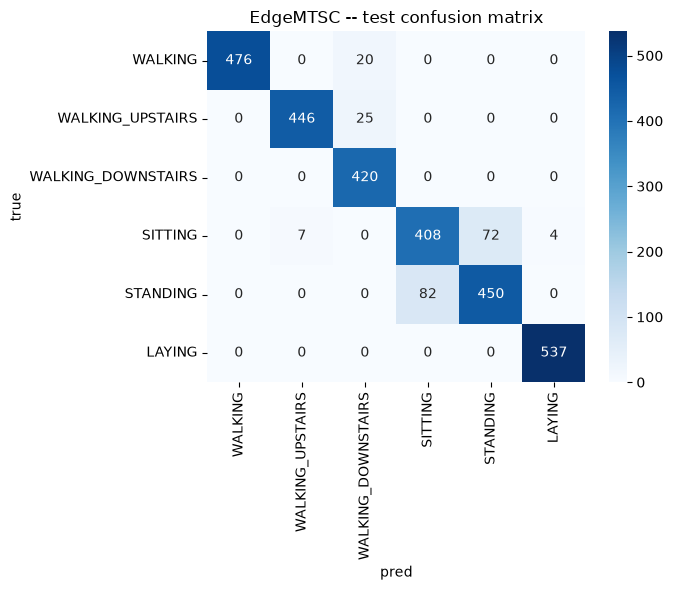

In [12]:
cm = confusion_matrix(test["y_true"], test["y_pred"])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap="Blues")
plt.xlabel("pred")
plt.ylabel("true")
plt.title("EdgeMTSC -- test confusion matrix")
plt.tight_layout()
plt.savefig(ROOT / "figures/01_edge_confusion.png", dpi=150)
plt.show()


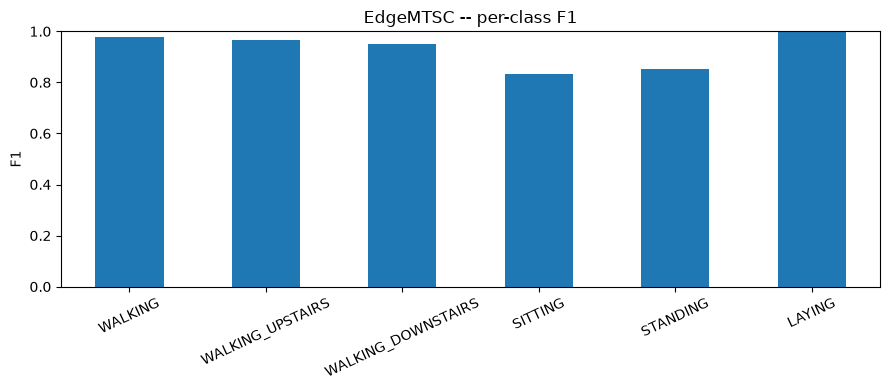

In [13]:
per_class_f1 = report.loc[CLASS_NAMES, "f1-score"]
per_class_f1.plot(kind="bar", figsize=(9, 4))
plt.ylim(0, 1)
plt.ylabel("F1")
plt.title("EdgeMTSC -- per-class F1")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(ROOT / "figures/01_edge_class_f1.png", dpi=150)
plt.show()


По классам картина ожидаемая: динамические активности и `LAYING` распознаются очень хорошо, а основные ошибки -- между `SITTING` и `STANDING`. У них F1 около `0.83-0.85`, тогда как у трех `WALKING*` и `LAYING` -- примерно `0.95-1.00`. Это совпадает с тем, что было видно еще на EDA.


Ожидаю, что самые неприятные ошибки будут между похожими статическими активностями и соседними видами ходьбы -- это нормальный sanity check для UCI HAR.


### Что выучил IMP

Показываю матрицу первого IMP. После `channel-fixing` это уже latent channels, не исходные 9 сенсоров, поэтому здесь интересна общая структура взаимодействий, а не физическая подпись конкретной оси.


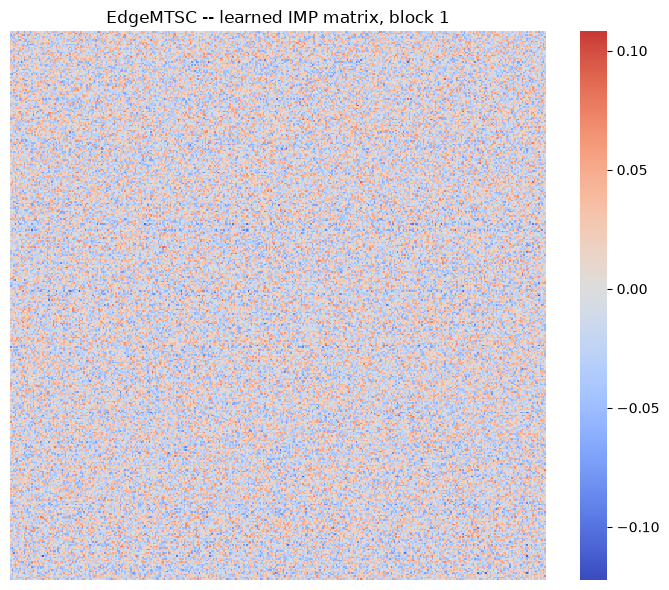

In [14]:
W = model.imp1.mix.weight.detach().cpu().numpy()
plt.figure(figsize=(7, 6))
sns.heatmap(W, center=0, cmap="coolwarm", xticklabels=False, yticklabels=False)
plt.title("EdgeMTSC -- learned IMP matrix, block 1")
plt.tight_layout()
plt.savefig(ROOT / "figures/01_edge_imp_matrix.png", dpi=150)
plt.show()


Матрица IMP получилась плотной и содержит веса обоих знаков -- модель не свелась к identity или одной доминирующей связи. Но это уже latent channels после `1x1 Conv`, поэтому физический смысл отдельных строк и столбцов не приписываю конкретным осям акселерометра. Этот график показывает, что mixing реально выучился, но сам по себе не доказывает его полезность -- для этого нужна ablation выше.


### Сохраняю результаты


In [15]:
result = {
    "model": "EdgeMTSC",
    "params": count_parameters(model),
    "cv_macro_f1_mean": cv_df["macro_f1"].mean(),
    "cv_macro_f1_std": cv_df["macro_f1"].std(),
    "cv_accuracy_mean": cv_df["accuracy"].mean(),
    "final_epochs": final_epochs,
    "test_accuracy": test["accuracy"],
    "test_balanced_accuracy": test["balanced_accuracy"],
    "test_macro_f1": test["macro_f1"],
    "train_time_s": final_train_time,
    "cv_time_s": cv_df["time_s"].sum(),
    "latency_ms": latency,
}

with open(ROOT / "results/01_edgemtsc.json", "w") as f:
    json.dump(result, f, indent=2)

cv_df.to_csv(ROOT / "results/01_edgemtsc_cv.csv", index=False)
ablation_df.to_csv(ROOT / "results/01_edge_ablation.csv", index=False)
result


{'model': 'EdgeMTSC',
 'params': 180232,
 'cv_macro_f1_mean': np.float64(0.9299504694467143),
 'cv_macro_f1_std': np.float64(0.06023705829315686),
 'cv_accuracy_mean': np.float64(0.9277768298835408),
 'final_epochs': 9,
 'test_accuracy': 0.9287410926365796,
 'test_balanced_accuracy': 0.9305701258147118,
 'test_macro_f1': 0.9293213375556711,
 'train_time_s': 17.66491320799105,
 'cv_time_s': np.float64(74.90276274998905),
 'latency_ms': 0.059980250625812914}